# Apache Polaris: the catalog in an open lakehouse

**A presentation notebook for PySpark learners**  
History • architecture • Hive comparison • SQL responsibilities • local lab plan

Prepared on **October 4, 2026**. Technical baseline: Polaris **1.8.0** documentation; your installed server version has not been verified.

This module teaches the complete picture before connecting to the local services. Later notebooks will implement the lab using your ports and credentials.

Source: [Polaris release history](https://polaris.apache.org/downloads/).

# 01 • What you should understand

- Explain why an Iceberg table needs a catalog even when all its files are in S3.
- Separate a query engine, table format, catalog service, and storage system.
- Trace a PySpark read and write through Polaris and object storage.
- Compare Polaris with Hive Metastore without confusing it with the whole Hive platform.
- Identify who performs DDL, DML, authorization, commits, and maintenance.
- Recognize the difference between S3A, S3FileIO, an HTTP endpoint, and a warehouse location.

**Prerequisites:** basic Spark DataFrames, SQL, files versus tables, and the idea of an object-storage bucket.

# 02 • Four components, four responsibilities

| Component | Responsibility | Example |
|---|---|---|
| Query engine | Plans SQL and runs distributed computation | Spark / PySpark |
| Table format | Defines snapshots, schemas and file tracking | Apache Iceberg |
| Catalog | Resolves table names and coordinates metadata commits | Apache Polaris |
| Storage | Persists data and metadata files | S3-compatible storage |

**Polaris does not contain your Spark executors or replace your storage bucket.** PySpark is Spark's Python interface; the Iceberg integration and REST client operate in Spark's JVM.

Sources: [Iceberg REST protocol](https://iceberg.apache.org/rest-catalog-spec/), [official Spark–Polaris guide](https://polaris.apache.org/guides/spark/).

# 03 • Why files alone are insufficient

Imagine two jobs writing new Parquet files for the same sales table. A directory listing does not identify a consistent schema, active snapshot, or valid set of files after both writes.

Iceberg tracks those relationships in metadata. The catalog gives engines a stable table identifier and the current metadata location, then coordinates updates to that reference.

**A folder of Parquet files is not automatically an Iceberg table.** Registering a name alone does not invent Iceberg manifests or transactional history.

Source: [Iceberg table specification](https://iceberg.apache.org/spec/).

# 04 • Who created Polaris? A short timeline

| When | Milestone |
|---|---|
| June 3, 2024 | Snowflake announced Polaris Catalog at Snowflake Summit |
| July 2024 | Polaris Catalog was released as open source |
| August 2024 | Apache incubation and infrastructure transition |
| July 9, 2025 | Apache Polaris 1.0.0 release |
| February 2026 | Graduation to an Apache top-level project; announcement February 19 |
| September 28, 2026 | Version 1.8.0 released |

Originally created at **Snowflake**, Polaris is now developed and governed by the **Apache community**. Distinguish Apache Polaris from Snowflake Open Catalog, a managed service built on Polaris.

Sources: [original announcement](https://www.snowflake.com/en/news/press-releases/snowflake-unveils-polaris-catalog-and-emphasizes-commitment-to-interoperability-with-aws-google-cloud-microsoft-azure-salesforce-and-more-2/), [open-source history](https://www.snowflake.com/en/blog/govern-open-lakehouse-snowflake-open-catalog/), [incubation record](https://incubator.apache.org/projects/polaris.html), [graduation](https://polaris.apache.org/blog/2026/02/19/apache-polaris-graduates-to-top-level-project/), [releases](https://polaris.apache.org/downloads/).

# 05 • Why Polaris exists

An open file format helps, but engines also need a shared way to discover tables, authenticate, obtain authorized storage access, and commit changes.

Polaris supplies an open implementation of the **Iceberg REST Catalog** interface. Multiple compatible engines can share a catalog rather than each maintaining isolated table registrations.

It addresses catalog interoperability and centralized access control. Actual portability still depends on engine capabilities, Iceberg versions, storage connectivity, and supported authentication.

**Useful outcome:** Spark writes a table; another compatible engine discovers the same table and reads its committed snapshot.

Sources: [Polaris project](https://github.com/apache/polaris), [graduation overview](https://polaris.apache.org/blog/2026/02/19/apache-polaris-graduates-to-top-level-project/).

# 06 • Apache governance and hosting choices

- Apache Polaris is an Apache License 2.0 open-source project.
- Snowflake's original contribution does not mean that Snowflake hosts every deployment.
- Self-hosting can use containers or Kubernetes; the operator manages service availability and persistence.
- A managed offering may add its own operational features, interfaces and commercial terms.

**Read feature claims carefully:** Apache project features, an optional extension, and a managed-service feature are different things.

Sources: [Apache repository and license](https://github.com/apache/polaris), [managed-service distinction](https://www.snowflake.com/en/blog/govern-open-lakehouse-snowflake-open-catalog/).

# 07 • Complete Spark–Polaris–storage architecture

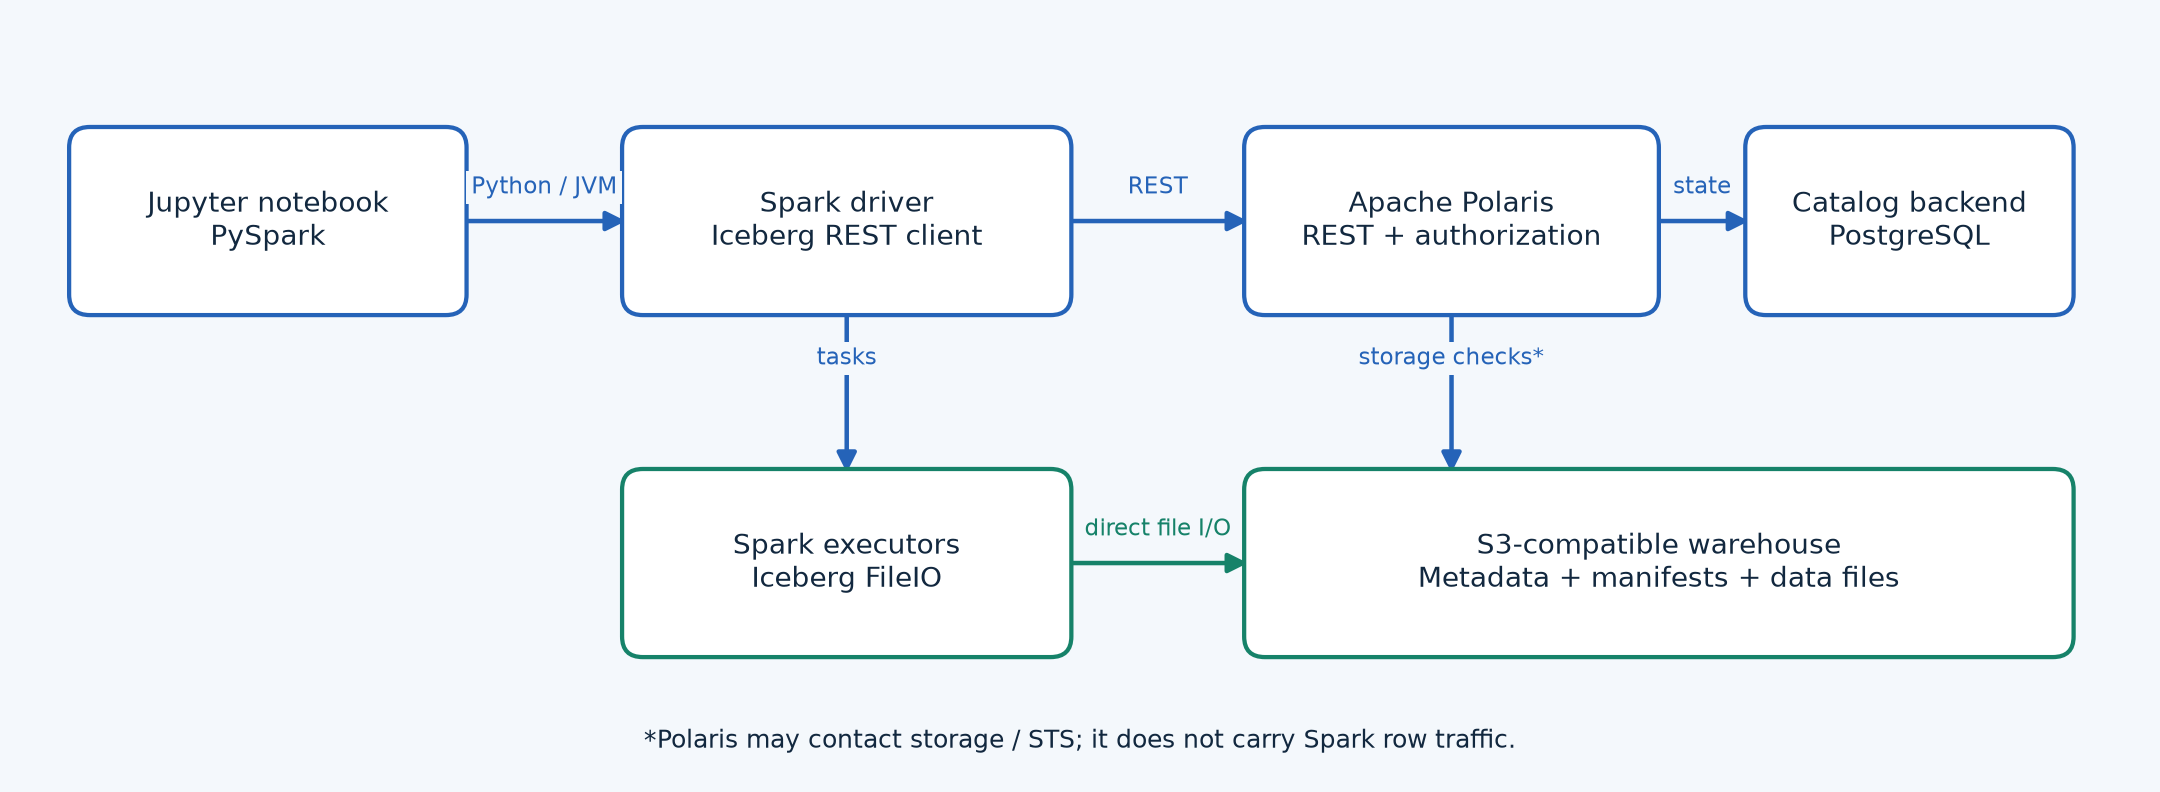

Blue arrows carry catalog/control requests. Green arrows carry file I/O. The backend database stores Polaris entities and catalog state; Iceberg metadata JSON, manifests and data files remain in object storage.

Sources: [REST specification](https://iceberg.apache.org/rest-catalog-spec/), [Polaris persistence](https://polaris.apache.org/releases/1.8.0/metastores/relational-jdbc/), [Iceberg S3FileIO](https://iceberg.apache.org/docs/latest/aws/).

# 08 • What is stored where?

| Place | Contents |
|---|---|
| Polaris persistence backend | Catalog entities, principals, roles, privileges, table records and metadata references |
| Warehouse object storage | Iceberg metadata JSON, manifest lists, manifests, data files and applicable delete files |
| Spark runtime | Query plans, execution tasks, caches, shuffle data and engine configuration |

The Polaris backend database is **not the sales-data warehouse**. The warehouse location is a file-storage prefix associated with table storage, not a relational database into which Polaris loads business rows.

Sources: [Polaris entities](https://polaris.apache.org/releases/1.8.0/entities/), [relational backend](https://polaris.apache.org/releases/1.8.0/metastores/relational-jdbc/), [Iceberg specification](https://iceberg.apache.org/spec/).

# 09 • Technology stack

| Layer | Technology / purpose |
|---|---|
| Server | Java and Quarkus service runtime |
| Build | Gradle; generated API models and services from OpenAPI definitions |
| Interfaces | Iceberg REST Catalog API plus Polaris management APIs |
| Engine integration | Iceberg REST client; Spark Iceberg runtime libraries |
| Durable persistence | Pluggable backends; relational JDBC supports PostgreSQL and H2 in 1.8.0 |
| Deployment | Containers; Kubernetes deployment through Helm |
| Identity | Built-in authentication or supported external identity-provider configuration |

Development examples may use in-memory persistence. Do not mistake that for a durable production metastore. Pin the actual server, JDK and connector versions when building the lab.

Sources: [code organization](https://github.com/apache/polaris), [JDBC support](https://polaris.apache.org/releases/1.8.0/metastores/relational-jdbc/), [identity providers](https://polaris.apache.org/releases/1.8.0/managing-security/external-idp/).

# 10 • The catalog naming model

```text
Polaris service
  └── catalog: lakehouse             ← managed Polaris catalog
       └── namespace: bronze
            └── table: suppliers

Spark SQL: polaris.bronze.suppliers
           └─────┘ └────┘ └───────┘
           alias   namespace table
```

The Spark alias `polaris` selects the configured client. Its `warehouse` setting identifies the Polaris catalog, for example `lakehouse`.

That catalog's default storage location might be `s3://training-lake/warehouse/`. The catalog name and storage URI serve different purposes; do not exchange them in configuration.

Sources: [Spark catalog configuration](https://iceberg.apache.org/docs/latest/spark-configuration/), [Polaris catalog creation](https://polaris.apache.org/releases/1.8.0/getting-started/creating-a-catalog/s3/catalog-minio/).

# 11 • How a read works

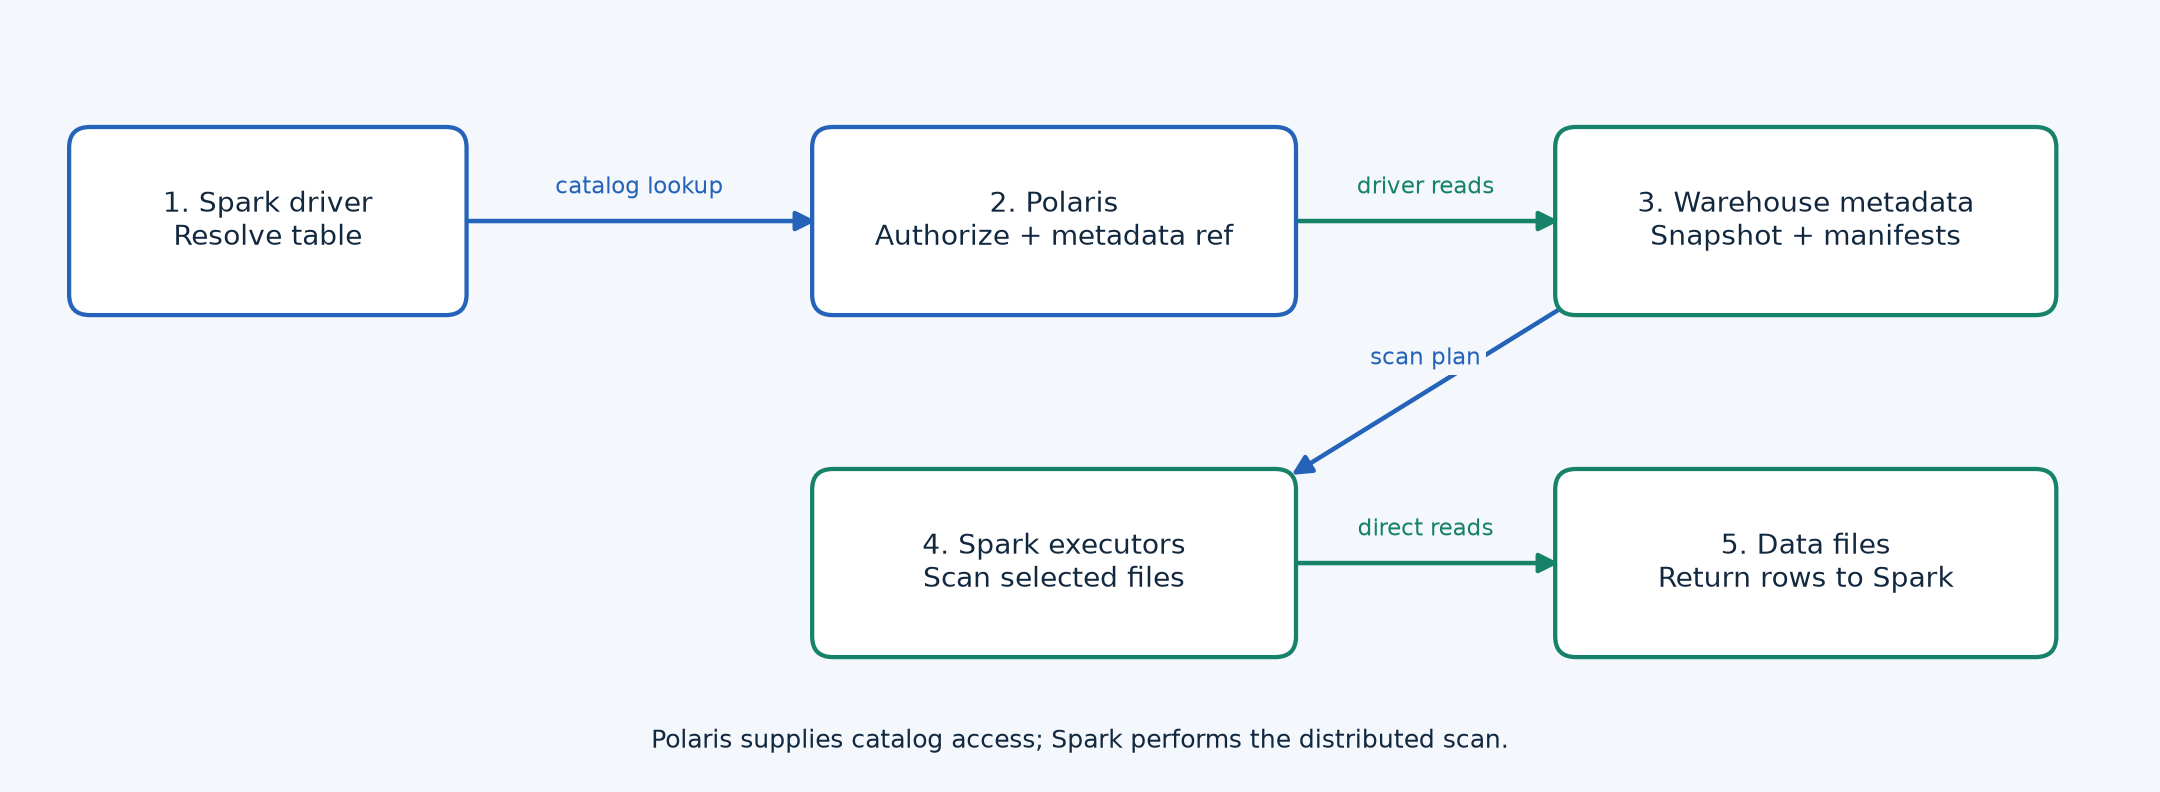

The driver uses the catalog to resolve and authorize the table. Iceberg uses snapshot metadata to plan the scan. Spark tasks read the selected files directly from storage.

Polaris is not a proxy streaming every Parquet row to Spark. Readers use a committed snapshot; cached metadata may require refresh before a new commit becomes visible.

Sources: [REST protocol](https://iceberg.apache.org/rest-catalog-spec/), [Spark queries](https://iceberg.apache.org/docs/latest/spark-queries/).

# 12 • How a write becomes visible

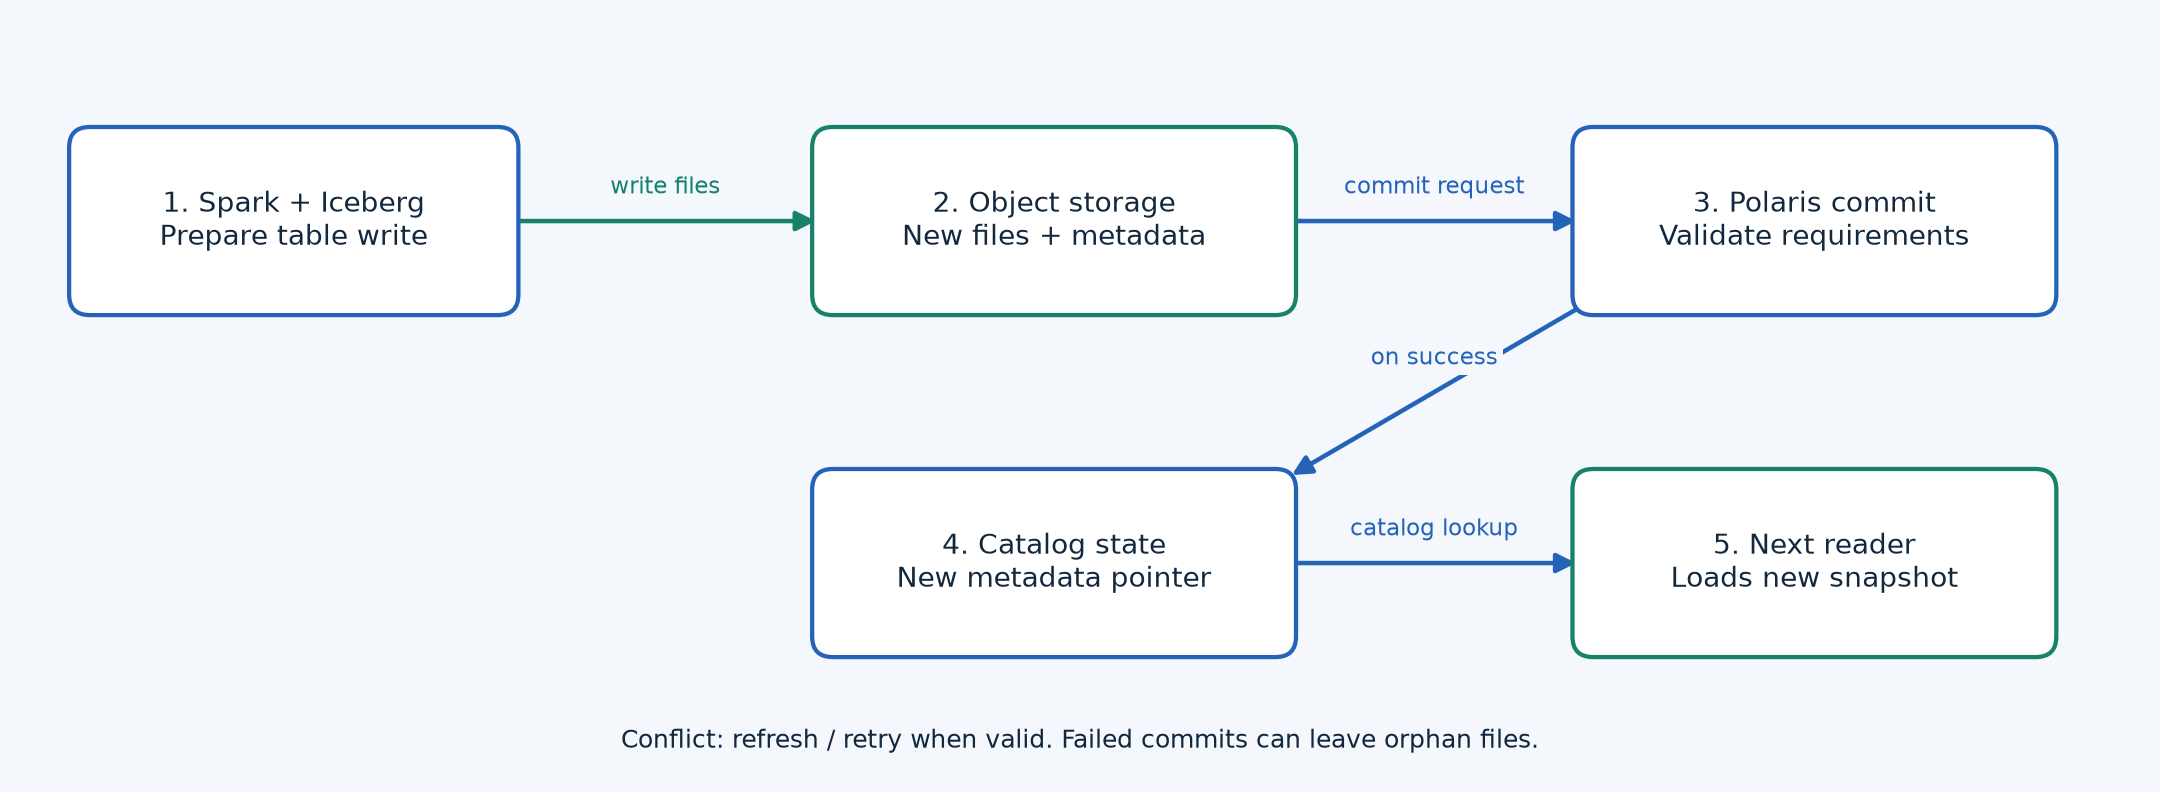

The engine writes new files and prepares metadata. A catalog commit validates requirements against current state and publishes the new table metadata reference.

If another writer changed relevant state, the commit can conflict; the client may refresh and retry according to operation semantics. Uncommitted files can remain for later orphan cleanup.

**Atomic visibility is a table-metadata property.** It does not imply that an arbitrary collection of Spark jobs updates every table as one database transaction.

Sources: [Iceberg REST commit API](https://iceberg.apache.org/rest-catalog-spec/), [Iceberg writes](https://iceberg.apache.org/docs/latest/spark-writes/).

# 13 • Polaris versus Hive: compare the right layers

Apache Hive includes a SQL system and a metastore. **Hive Metastore (HMS)** is its metadata service and is also used by other engines.

The direct catalog comparison is **Polaris versus HMS**, not Polaris versus all of Hive. An Iceberg `HiveCatalog` can use HMS; an Iceberg `RESTCatalog` can use Polaris.

HMS is not incapable of managing Iceberg tables. Polaris offers a REST-oriented catalog and a built-in access-control model suited to sharing Iceberg tables among compatible engines.

Sources: [Hive engine architecture](https://hive.apache.org/docs/latest/user/hive-on-spark/), [Iceberg integration with Hive](https://iceberg.apache.org/docs/latest/hive/), [Polaris access control](https://polaris.apache.org/releases/1.8.0/managing-security/access-control/).

# 14 • Catalog comparison

| Question | Hive Metastore workflow | Polaris workflow |
|---|---|---|
| Typical catalog connection | HMS client / Thrift | Iceberg REST client / HTTP |
| Spark Iceberg implementation | HiveCatalog | RESTCatalog |
| Existing Hive ecosystem | Native fit for HMS-based tooling | Check REST support or federation |
| Catalog authorization | Depends on metastore and security integration | Principals, principal roles, catalog roles and privileges |
| File access | Engine needs storage access | Engine needs storage access; credential vending may help |
| SQL execution | HMS does not execute SQL | Polaris does not execute SQL |

Choose from actual interoperability and governance needs. A catalog change does not automatically migrate Hive SerDe tables into Iceberg.

Sources: [Iceberg Hive integration](https://iceberg.apache.org/docs/latest/hive/), [Polaris RBAC](https://polaris.apache.org/releases/1.8.0/managing-security/access-control/), [HMS federation](https://polaris.apache.org/releases/1.8.0/federation/hive-metastore-federation/).

# 15 • What about HDFS?

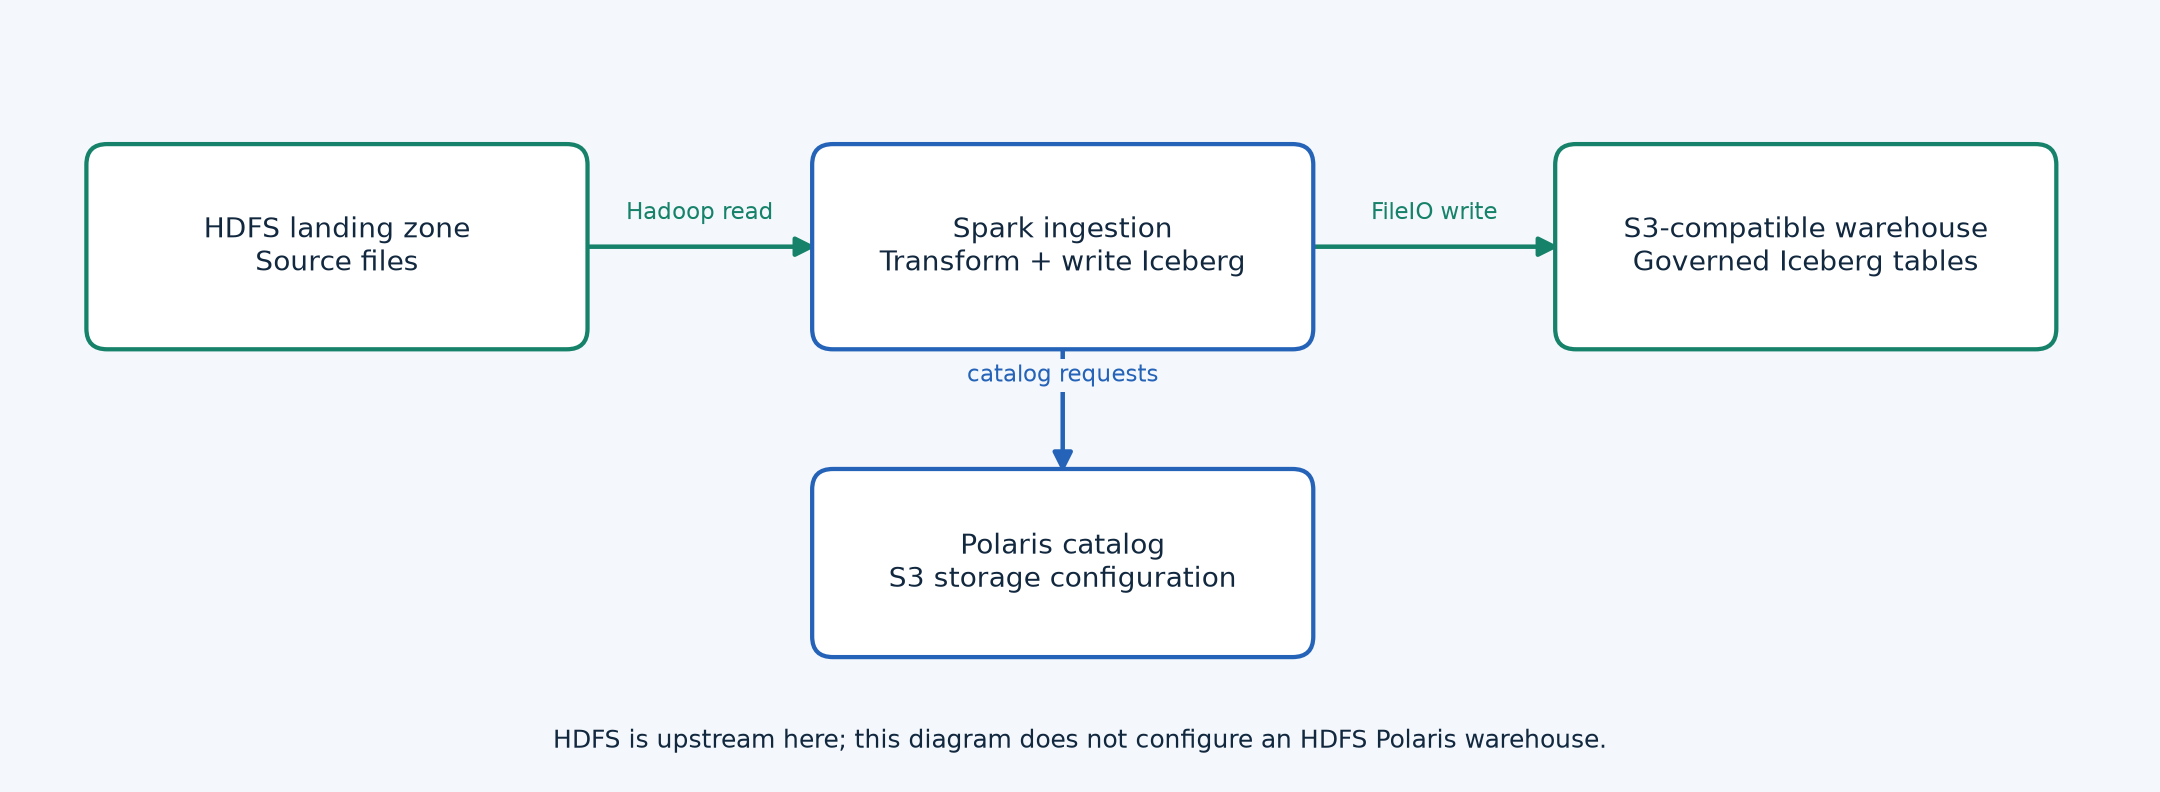

Spark and Iceberg can operate with Hadoop filesystem integrations, including HDFS in suitable deployments. That does not establish that an arbitrary HDFS location is a supported Polaris warehouse.

Polaris 1.8.0 documents S3, Azure and GCS storage types, with FILE for testing; it does not document an HDFS storage type. This course uses S3-compatible storage for Polaris-managed tables and can use HDFS as an upstream landing zone.

Source: [Polaris storage types](https://polaris.apache.org/releases/1.8.0/entities/). Diagram: proposed course design, not a claim about the current local deployment.

# 16 • S3A versus S3FileIO

| Integration | Location example | Important configuration |
|---|---|---|
| Hadoop S3A connector | `s3a://bucket/path/` | `fs.s3a.*`; matching Hadoop AWS dependencies |
| Iceberg S3FileIO | Typically `s3://bucket/path/` | `s3.*`; Iceberg AWS dependencies |
| S3 API endpoint | `http://localhost:9001` | HTTP host and port, not a bucket URI |

S3A is a filesystem connector, not a server. The two I/O paths can reach the same S3-compatible store, but their dependency and credential settings differ.

Do not assume that setting `fs.s3a.endpoint` configures Iceberg S3FileIO. Select one path deliberately and verify its effective configuration.

Sources: [Hadoop S3A](https://hadoop.apache.org/docs/stable/hadoop-aws/tools/hadoop-aws/index.html), [Iceberg AWS storage](https://iceberg.apache.org/docs/latest/aws/).

# 17 • Two kinds of credentials

| Credential | Purpose |
|---|---|
| Polaris client ID / client secret | Obtain a catalog access token and authenticate catalog requests |
| S3 access key / secret key | Sign object-storage requests |
| Temporary storage credentials | Access permitted locations for a bounded session where vending is configured |

The lab uses the same supplied values for the first two credential pairs, but they represent separate authentication domains.

An interactive username/password is not automatically an OAuth client credential. Later we will verify how `team` is configured in your Polaris deployment.

Sources: [Polaris identity providers](https://polaris.apache.org/releases/1.8.0/managing-security/external-idp/), [vended credential reference](https://polaris.apache.org/releases/1.8.0/vended-credentials/).

# 18 • Role-based access control

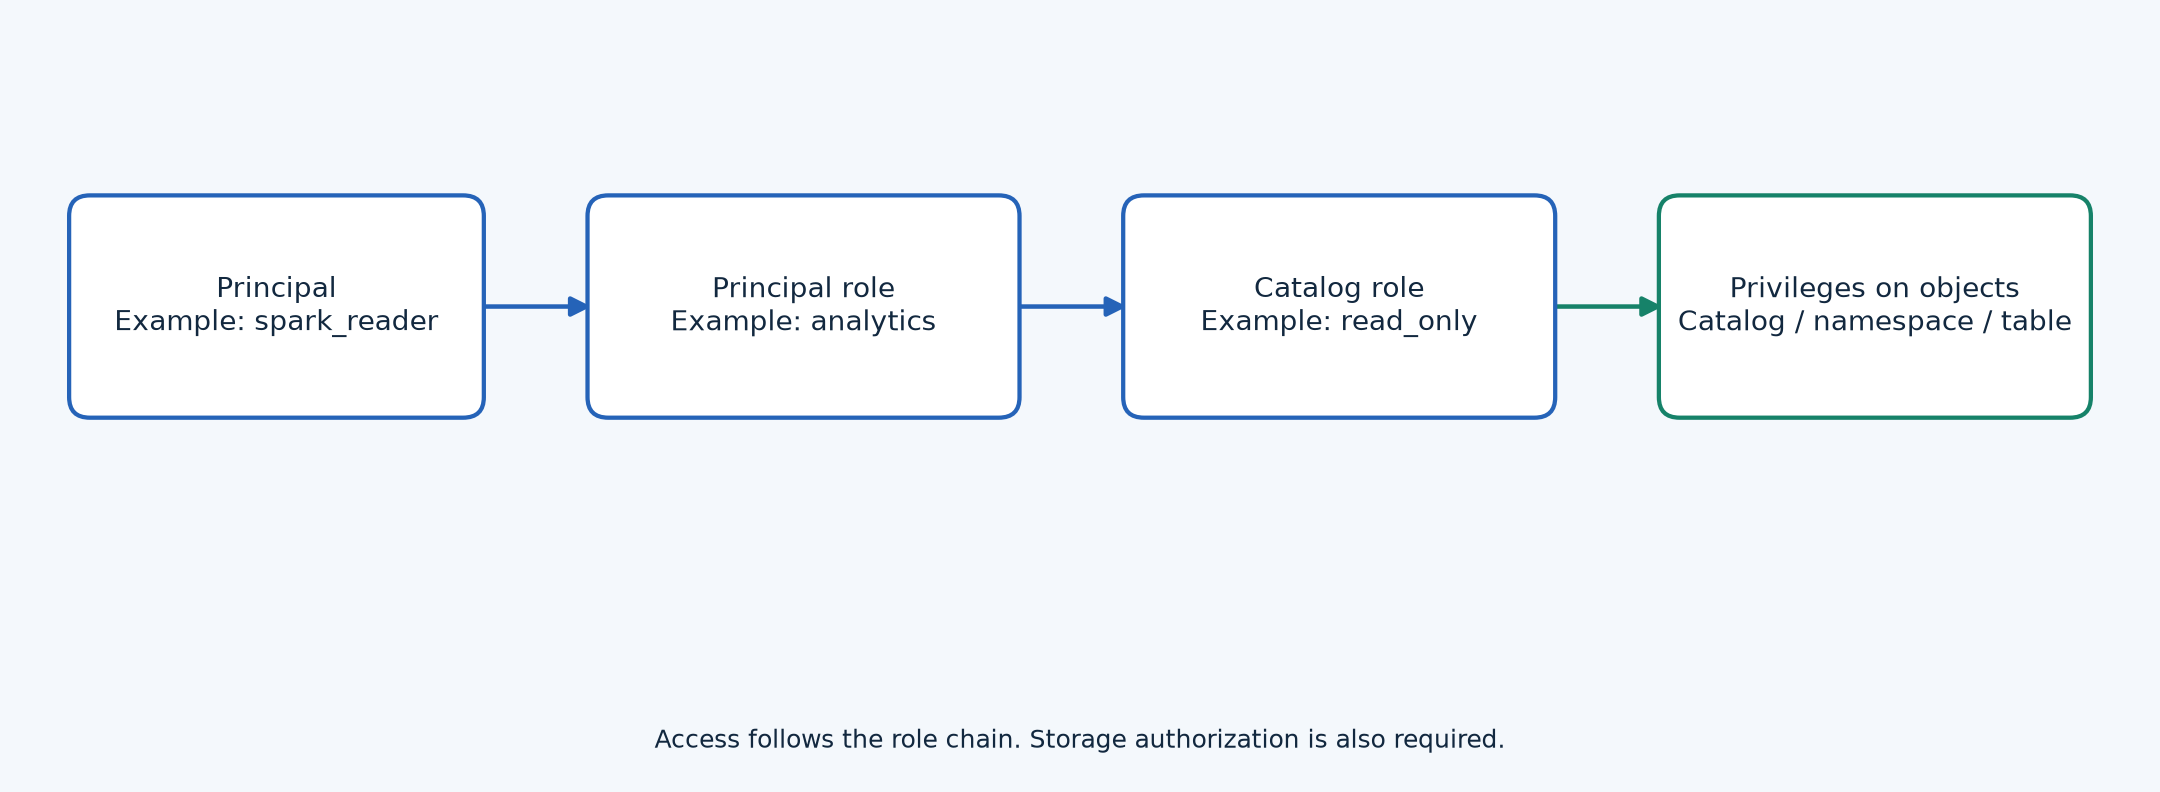

A principal represents a user or service identity. Principal roles group identities; catalog roles collect privileges on catalog objects. Catalog roles are granted to principal roles, which are granted to principals.

For our future course, define a reader and a writer separately. Demonstrate that a reader can discover and read a table but cannot create or modify it.

Storage permissions must agree with catalog permissions. Broad independent bucket keys can bypass the catalog's intended access boundary.

Source: [Polaris RBAC](https://polaris.apache.org/releases/1.8.0/managing-security/access-control/). Reader/writer roles are a proposed lab design.

# 19 • Additional Polaris features

- **Credential vending:** returns supported temporary storage credentials and configuration when enabled; availability depends on the backend and identity setup.
- **External identity providers:** integrate supported token validation and identity configuration.
- **Federation:** access external catalogs through Polaris; HMS federation needs an optional extension and configuration.
- **Telemetry:** metrics, logs and tracing support service operations.
- **Generic tables:** beta registration for non-Iceberg formats through separate APIs.

These are not automatic features of every running container. Check the server release, configuration and client support.

Sources: [vending](https://polaris.apache.org/releases/1.8.0/vended-credentials/), [identity](https://polaris.apache.org/releases/1.8.0/managing-security/external-idp/), [federation](https://polaris.apache.org/releases/1.8.0/federation/hive-metastore-federation/), [telemetry](https://polaris.apache.org/releases/1.8.0/telemetry/), [generic tables](https://polaris.apache.org/releases/1.8.0/generic-table/).

# 20 • Generic tables: understand the boundary

Polaris 1.8.0 documents beta generic-table APIs for registering formats such as Delta or CSV. A registration stores a format and location with properties.

The documentation lists important limits: generic tables do not receive Iceberg commit coordination, schema/partition specifications, updates through that API, or credential vending.

**Registering a CSV as a generic table does not give it Iceberg snapshots, MERGE semantics, or ACID behavior.** Those capabilities require the relevant format and engine integration.

Source: [generic-table APIs and limitations](https://polaris.apache.org/releases/1.8.0/generic-table/).

# 21 • Who performs DDL?

| Operation | Spark + Iceberg client | Polaris |
|---|---|---|
| CREATE NAMESPACE | Parses SQL and sends catalog request | Authorizes and records namespace |
| CREATE TABLE USING iceberg | Builds schema and table metadata | Authorizes and registers the table |
| ALTER TABLE | Produces metadata updates | Validates and commits catalog changes |
| SHOW / DESCRIBE | Presents results to the user | Provides permitted catalog information |
| DROP TABLE | Sends drop; purge behavior depends on request/version | Authorizes removal of catalog registration |

Polaris exposes catalog operations; it does **not** run a SQL parser or execute `spark.sql(...)`. Removing a registration and physically deleting table files are different actions.

Sources: [Iceberg Spark DDL](https://iceberg.apache.org/docs/latest/spark-ddl/), [Iceberg REST API](https://iceberg.apache.org/rest-catalog-spec/).

# 22 • DDL examples for the later lab

These statements are illustrative and **are not executed by this notebook**. They assume Spark alias `polaris` points to an existing Polaris catalog.

```sql
CREATE NAMESPACE IF NOT EXISTS polaris.bronze;

CREATE TABLE polaris.bronze.suppliers (
  supplier_ref STRING,
  supplier_name STRING,
  updated_at TIMESTAMP
) USING iceberg;

ALTER TABLE polaris.bronze.suppliers
  ADD COLUMN country STRING;

SHOW TABLES IN polaris.bronze;
```

Creating the top-level Polaris catalog, configuring its storage, and granting roles are management tasks completed before this SQL.

Source: [Spark DDL](https://iceberg.apache.org/docs/latest/spark-ddl/).

# 23 • DML, queries and maintenance

| Work | Main owner |
|---|---|
| SELECT, joins, aggregations | Spark or another query engine |
| INSERT, UPDATE, DELETE, MERGE | Engine plus Iceberg implementation; support depends on versions and extensions |
| Snapshot metadata commit | Catalog API and Iceberg commit protocol |
| Time-travel reads | Iceberg snapshots interpreted by a compatible engine |
| File compaction, snapshot expiration, orphan cleanup | Scheduled Iceberg maintenance jobs |

Polaris can authorize relevant catalog access and commits; it does not scan and rewrite rows for a MERGE or automatically optimize every table.

Sources: [Spark writes](https://iceberg.apache.org/docs/latest/spark-writes/), [Spark queries](https://iceberg.apache.org/docs/latest/spark-queries/), [maintenance](https://iceberg.apache.org/docs/latest/maintenance/).

# 24 • What Polaris cannot supply by itself

- A SQL execution engine, Spark cluster, or BI dashboard.
- Automatic Odoo extraction, CDC ingestion, orchestration, or data-quality rules.
- Parquet-to-Iceberg conversion merely by pointing a catalog at a directory.
- Universal compatibility with every engine and table-format version.
- Automatic small-file compaction or unlimited historical retention.
- A general distributed transaction across arbitrary tables and applications.
- Row filtering or column masking merely because catalog RBAC is enabled; evaluate specific policy and engine support.

For a complete lakehouse, combine catalog, compute, storage, ingestion, scheduling and appropriate governance integrations.

Sources: [project scope](https://polaris.apache.org/guides/spark/), [Iceberg maintenance](https://iceberg.apache.org/docs/latest/maintenance/), [catalog privileges](https://polaris.apache.org/releases/1.8.0/managing-security/access-control/).

# 25 • Your Odoo-to-lakehouse course architecture

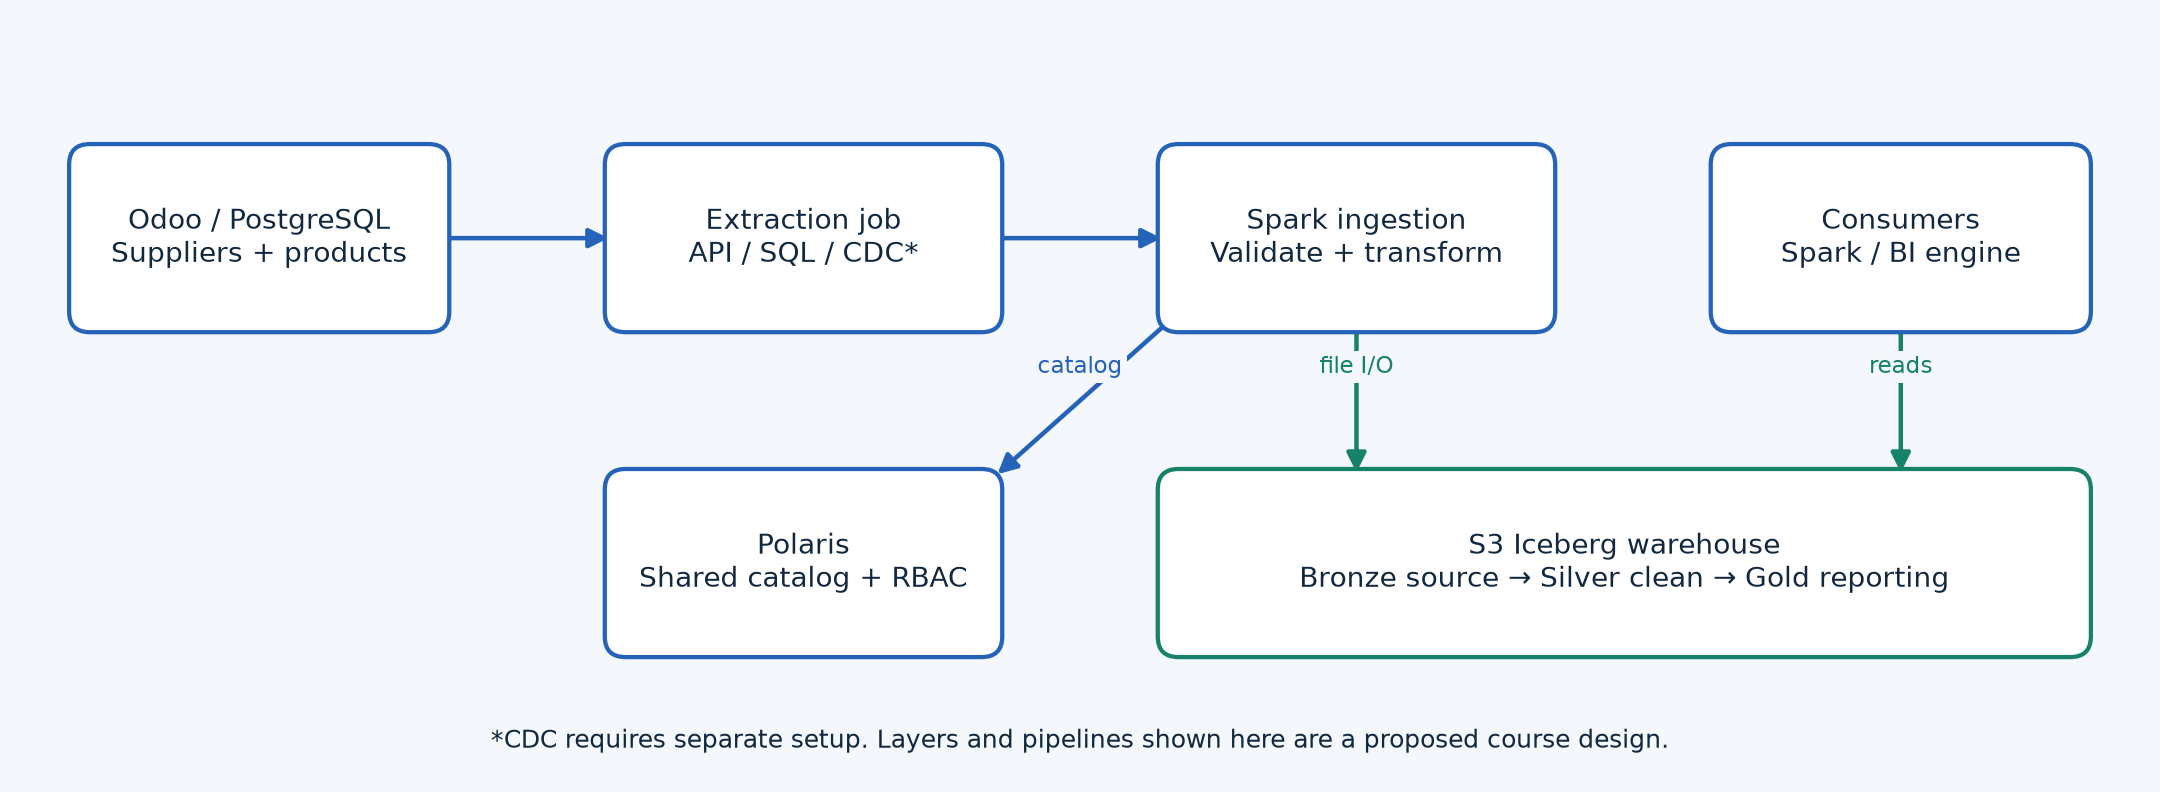

Use stable source keys such as supplier references and product stock codes in the analytical model. Preserve extraction timestamps and source identifiers.

Bronze retains ingested source records; silver validates and standardizes them; gold exposes reporting dimensions and facts. These are design conventions, not automatic Polaris transformations.

This is a **proposed next-stage architecture**. No extractor, CDC pipeline, bucket, catalog or Iceberg table is created in this introduction.

# 26 • Local service contract for future notebooks

| Setting | User-supplied value | Status |
|---|---|---|
| Polaris base URL | `http://localhost:8880` | Record for later connection |
| Expected catalog API path | `/api/catalog` | Verify deployed routing/version |
| S3-compatible endpoint | `http://localhost:9001` | Verify this is the S3 API |
| Polaris identity / S3 access key | `team` | Same value; separate purposes |
| Secret / password | Kept in `local-lab.env.example` | Supplied local demo credential |
| Catalog, bucket and region | To be determined | Do not invent existing names |

No live checks are performed here. If the store is MinIO, API and browser-console ports may differ; do not silently change your supplied port.

Source for endpoint behavior: [Polaris MinIO configuration](https://polaris.apache.org/releases/1.8.0/getting-started/creating-a-catalog/s3/catalog-minio/).

# 27 • PySpark catalog configuration: read the settings

This function only returns a configuration dictionary. It starts no Spark session and contacts no service.

```python
def polaris_catalog_settings(catalog_name):
    return {
        "spark.sql.extensions":
            "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions",
        "spark.sql.catalog.polaris":
            "org.apache.iceberg.spark.SparkCatalog",
        "spark.sql.catalog.polaris.type": "rest",
        "spark.sql.catalog.polaris.uri":
            "http://localhost:8880/api/catalog",
        "spark.sql.catalog.polaris.warehouse": catalog_name,
    }
```

Authentication, OAuth token configuration, FileIO, credentials and dependency versions will be supplied in the runnable lab. An existing catalog name must replace the parameter.

Source: [Iceberg Spark configuration](https://iceberg.apache.org/docs/latest/spark-configuration/).

In [ ]:
def polaris_catalog_settings(catalog_name):
    return {
        "spark.sql.extensions":
            "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions",
        "spark.sql.catalog.polaris":
            "org.apache.iceberg.spark.SparkCatalog",
        "spark.sql.catalog.polaris.type": "rest",
        "spark.sql.catalog.polaris.uri":
            "http://localhost:8880/api/catalog",
        "spark.sql.catalog.polaris.warehouse": catalog_name,
    }

# 28 • Networking: whose localhost?

| Execution location | Meaning of localhost |
|---|---|
| Notebook on the Windows host | The Windows host |
| Spark driver in a container | That driver container |
| Executor in another container/node | That executor's own container/node |
| Polaris inside Docker | The Polaris container |

Every process that accesses a service needs a reachable endpoint. A driver reaching `localhost:9001` does not prove executors or Polaris can reach storage.

For later Docker labs, choose service DNS names or a reachable host address and account for separate internal/client endpoints where supported. Keep warehouse file locations consistent across engines.

Source for separate endpoints: [Polaris MinIO catalog setup](https://polaris.apache.org/releases/1.8.0/getting-started/creating-a-catalog/s3/catalog-minio/). Network examples are explanatory scenarios.

# 29 • A complete deployment includes operations

- Persist and back up the catalog backend as well as the warehouse files; neither backup alone reconstructs everything.
- Configure health checks, service logs, metrics and tracing.
- Match Spark, Scala, Java and Iceberg runtime dependencies; avoid duplicate conflicting JARs.
- Schedule compaction and retention deliberately; protect active readers and writers during cleanup.
- Use supported credential and identity configuration; catalog properties can be client-visible.

In-memory catalog persistence is useful for demonstrations, but a restart can lose registrations. Durable files in a bucket do not repair a lost catalog automatically.

Sources: [persistence](https://polaris.apache.org/releases/1.8.0/metastores/relational-jdbc/), [telemetry](https://polaris.apache.org/releases/1.8.0/telemetry/), [maintenance](https://iceberg.apache.org/docs/latest/maintenance/), [catalog properties](https://polaris.apache.org/releases/1.8.0/entities/).

# 30 • Planned hands-on notebook sequence

1. **Connectivity and versions:** identify the S3 API, Polaris version, Spark runtime and authentication mode.
2. **Catalog setup:** create or reuse bucket/catalog; configure warehouse location and reader/writer privileges.
3. **PySpark integration:** configure the REST catalog and selected FileIO; list namespaces.
4. **DDL and DML:** create supplier/product tables, seed data, evolve schemas and demonstrate MERGE.
5. **Iceberg internals:** inspect snapshots, manifests and time-travel behavior.
6. **Odoo pipeline:** load source exports into bronze, then build supplier/product dimensions and facts.
7. **Governance and maintenance:** verify denied writes for readers, exercise supported credentials, and schedule cleanup.

These later modules will use your supplied ports. This introduction remains usable without running services.

# 31 • Check your understanding

1. Where are the Parquet rows stored: Polaris's database or the object store?
2. Who executes `MERGE INTO`: Polaris or Spark with Iceberg?
3. Why does the Spark alias differ from the managed catalog name?
4. Does changing a catalog convert a legacy Hive table to Iceberg?
5. Does S3A configuration automatically configure S3FileIO?
6. Does catalog RBAC protect a bucket when a user has independent unrestricted bucket credentials?

**Answers:** object store; Spark/Iceberg; client alias and server entity are separate; no; no; not by itself.

**Architecture exercise:** trace a supplier-table write from notebook to driver, executors, storage files, catalog commit and the next reader.

# 32 • Official references: history and catalog

- [Snowflake's original announcement](https://www.snowflake.com/en/news/press-releases/snowflake-unveils-polaris-catalog-and-emphasizes-commitment-to-interoperability-with-aws-google-cloud-microsoft-azure-salesforce-and-more-2/)
- [Open-source and managed-service history](https://www.snowflake.com/en/blog/govern-open-lakehouse-snowflake-open-catalog/)
- [Apache incubation record](https://incubator.apache.org/projects/polaris.html)
- [Apache graduation announcement](https://polaris.apache.org/blog/2026/02/19/apache-polaris-graduates-to-top-level-project/)
- [Apache repository and license](https://github.com/apache/polaris)
- [Release history](https://polaris.apache.org/downloads/)
- [Entities and storage types](https://polaris.apache.org/releases/1.8.0/entities/)
- [Catalog role-based access](https://polaris.apache.org/releases/1.8.0/managing-security/access-control/)
- [Persistence backends](https://polaris.apache.org/releases/1.8.0/metastores/relational-jdbc/)

Verified against official sources on October 4, 2026. Installed-service compatibility will be checked in the later labs.

# 33 • Official references: integrations and operations

- [Official Spark–Polaris guide](https://polaris.apache.org/guides/spark/)
- [MinIO / S3-compatible configuration](https://polaris.apache.org/releases/1.8.0/getting-started/creating-a-catalog/s3/catalog-minio/)
- [Credential vending](https://polaris.apache.org/releases/1.8.0/vended-credentials/)
- [Identity providers](https://polaris.apache.org/releases/1.8.0/managing-security/external-idp/)
- [Hive Metastore federation](https://polaris.apache.org/releases/1.8.0/federation/hive-metastore-federation/)
- [Generic tables and limits](https://polaris.apache.org/releases/1.8.0/generic-table/)
- [Polaris telemetry](https://polaris.apache.org/releases/1.8.0/telemetry/)
- [Iceberg REST protocol](https://iceberg.apache.org/rest-catalog-spec/)
- [Iceberg table specification](https://iceberg.apache.org/spec/)
- [Hive SQL engine context](https://hive.apache.org/docs/latest/user/hive-on-spark/)

# 34 • Official references: Spark and storage

- [Spark catalog configuration](https://iceberg.apache.org/docs/latest/spark-configuration/)
- [Spark DDL](https://iceberg.apache.org/docs/latest/spark-ddl/)
- [Spark writes and MERGE](https://iceberg.apache.org/docs/latest/spark-writes/)
- [Spark queries and time travel](https://iceberg.apache.org/docs/latest/spark-queries/)
- [Iceberg maintenance](https://iceberg.apache.org/docs/latest/maintenance/)
- [Iceberg AWS / S3FileIO](https://iceberg.apache.org/docs/latest/aws/)
- [Iceberg and Hive integration](https://iceberg.apache.org/docs/latest/hive/)
- [Hadoop S3A connector](https://hadoop.apache.org/docs/stable/hadoop-aws/tools/hadoop-aws/index.html)

The Markdown, presentation notebook and PDF contain the same lesson. Architecture diagrams are also supplied as editable SVG and high-resolution PNG assets.